# Метрические алгоритмы

В практической части проекта тебе предстоит научиться различать виды 
пингвинов по их морфологическим характеристикам. В этом тебе поможет метод 
ближайших соседей (k-NN), который будет классифицировать пингвинов на основе 
сходства их признаков с уже известными примерами.

![Описание признаков пингвинов](../misc/images/penguin.png)

## Задание 1. Изучение датасета

В этом задании ты будешь работать с датасетом Palmer Penguins. Этот датасет 
содержит измерения различных характеристик пингвинов трех видов: Adélie, 
Chinstrap и Gentoo. Подробное описание датасета можно найти на 
[официальном сайте](https://allisonhorst.github.io/palmerpenguins/).

Данные включают в себя морфологические измерения пингвинов: длину и глубину 
клюва (culmen), длину ласт (flipper), массу тела и другие характеристики. 
Эти измерения позволяют различать виды пингвинов, поэтому датасет подходит 
для практического изучения метрических алгоритмов классификации.


Давай познакомимся с данными и шаг за шагом разберемся, как с ними работать:

1. **Загрузка данных:**
   - Загрузи датасет из файла `datasets/penguins_size.csv`.
   - Выведи размерность датасета.

2. **Разведочный анализ данных (EDA):**
   - Изучи, какие признаки (столбцы) присутствуют в датасете.
   - Удали строки, в которых отсутствует хотя бы одно значение.
   - Определи, какой столбец является целевой переменной (Y) для задачи 
   классификации, а какие столбцы будут использоваться в качестве 
   признаков (X).

3. **Разделение данных:**
   - Раздели датасет на обучающую (train) и тестовую (test) выборки в 
   соотношении 70% к 30% соответственно.
   - Используй `random_state=42` для воспроизводимости результатов.
   - Выведи размеры обеих выборок.

4. **Визуализация признаков:**
   - Построй график рассеяния (scatter plot), на котором будут одновременно отображены обе выборки — обучающая и тестовая.
   - Для визуализации используй два признака из набора данных: 
   длину клюва (ось X) и длину ласт (ось Y).
   - Для обучающей выборки (train): окрась точки в разные 
   цвета в соответствии с классами (видами пингвинов). Используй легенду, 
   чтобы показать соответствие цветов классам.
   - Для тестовой выборки (test): окрась все точки серым цветом, чтобы 
   визуально показать, что их классы нам неизвестны (именно их мы будем 
   предсказывать с помощью алгоритма k-NN).
   - Добавь подписи осей и заголовок графика.

In [40]:
import pandas as pd
df = pd.read_csv("C://Users/User/Desktop/ml2/AI_Machine_Learning_Project_2.ID_1577772-1/datasets/penguins_size.csv")
df.shape

(344, 7)

In [41]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [42]:
df = df.dropna(axis=0)

In [43]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size= 0.3,
    random_state= 42,
    shuffle=True,
    stratify= df['species']
)

print(train.shape, test.shape)

(233, 7) (101, 7)


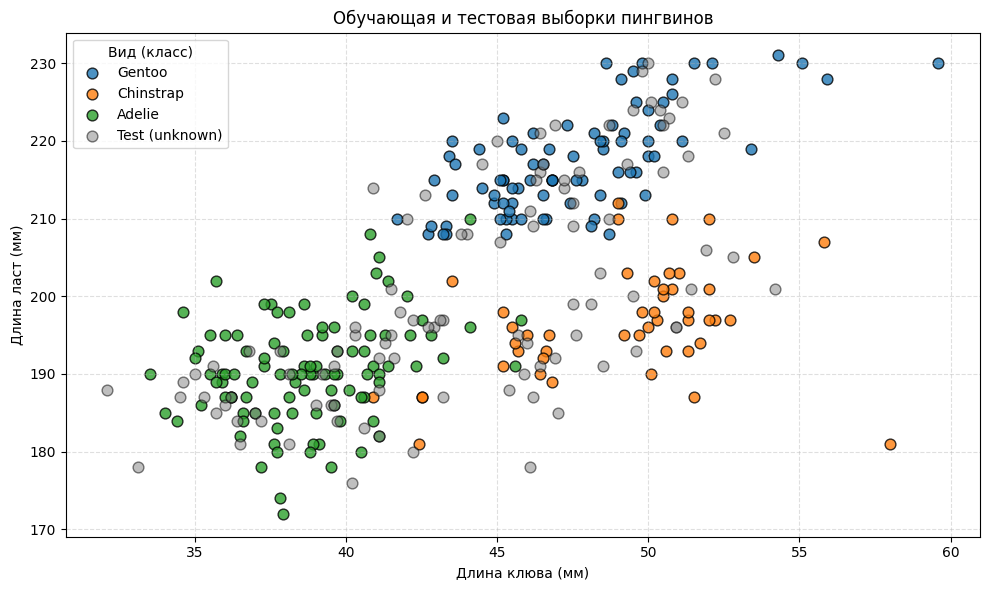

In [44]:
import matplotlib.pyplot as plt

species_list = train['species'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # подойдут для трёх классов
color_dict = dict(zip(species_list, colors))

# 4. Построение графика только с помощью plt
plt.figure(figsize=(10, 6))

# Обучающая выборка — каждая точка окрашена по классу
for sp in species_list:
    mask = train['species'] == sp
    plt.scatter(
        train.loc[mask, 'culmen_length_mm'],
        train.loc[mask, 'flipper_length_mm'],
        color=color_dict[sp],
        label=sp,
        alpha=0.8,
        edgecolor='k',
        s=60
    )

# Тестовая выборка — все точки серым цветом
plt.scatter(
    test['culmen_length_mm'],
    test['flipper_length_mm'],
    color='gray',
    alpha=0.5,
    edgecolor='k',
    s=60,
    label='Test (unknown)'
)

# Оформление
plt.xlabel('Длина клюва (мм)')
plt.ylabel('Длина ласт (мм)')
plt.title('Обучающая и тестовая выборки пингвинов')
plt.legend(title='Вид (класс)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Задание 2. Метрики

На построенном графике рассеяния ты видишь 3 больших кластера в пространстве признаков длины клюва и длины ласт. Каждый кластер соответствует одному из видов пингвинов. Теперь для серых точек (тестовой выборки) нужно найти ближайшие точки из обучающей выборки, чтобы понять, к какому классу их отнести.

Для определения функции расстояния между точками в пространстве признаков существуют различные метрики. В этом задании ты реализуешь несколько основных метрик расстояния, которые используются в метрических алгоритмах.

1. **Реализуй метрику Минковского:**
   - Метрика Минковского — это обобщенная метрика расстояния, которая 
   включает в себя множество других метрик как частные случаи.
   - Формула метрики Минковского для двух точек 
   
   $p = (p_1, p_2, ..., p_n)$ и $q = (q_1, q_2, ..., q_n)$:
   $$d(p, q) = \left(\sum_{i=1}^{n} |p_i - q_i|^p\right)^{1/p}$$
   
   где $p$ — параметр метрики (не путай с точкой $p$).
   - Реализуй функцию `minkowski_distance(point1, point2, p)`, которая 
   принимает две точки (массивы или списки) и параметр $p$, и возвращает 
   расстояние Минковского между ними.


2. **Реализуй евклидову и манхэттенскую метрики:**
   - Евклидова метрика — это частный случай метрики Минковского при $p = 2$.
   Это стандартное расстояние между точками в евклидовом пространстве, 
   которое ты изучал в геометрии.
   - Манхэттенская метрика (также известная как метрика L1 или 
   «city block distance») — это частный случай метрики Минковского при 
   $p = 1$. Название происходит от того, что это расстояние, которое нужно 
   пройти по улицам прямоугольной сетки (как в Манхэттене), где можно 
   двигаться только горизонтально и вертикально.
   - Реализуй функции `euclidean_distance(point1, point2)` и 
   `manhattan_distance(point1, point2)`, используя реализованную ранее 
   метрику Минковского.


3. **Расчет расстояния:**
   - Для точки из тестовой выборки с минимальным `culmen_length_mm` 
   рассчитай манхэттенское расстояние от точки (45, 200).
   - Для точки из тестовой выборки с максимальным `flipper_length_mm` 
   рассчитай евклидово расстояние от точки (45, 200).
   - Визуализируй только эти точки и точку (45, 200). 

In [45]:
def minkowski_distance(point1, point2, p):
    return ( abs(point1[0] - point2[0])**p + abs(point1[1] - point2[1])**p )**1/p

def euclidean_distance(point1, point2):
    return minkowski_distance(point1, point2, 2)

def manhattan_distance(point1, point2):
    return minkowski_distance(point1, point2, 1)

In [46]:
test[test['culmen_depth_mm'] == test['culmen_depth_mm'].min()]


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,FEMALE


In [47]:
manhattan_distance([46.1, 211.0], [45, 200])

12.100000000000001

In [48]:
test[test['flipper_length_mm'] == test['flipper_length_mm'].max()]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE


In [49]:
euclidean_distance([50.0, 230.0], [45, 200])

462.5

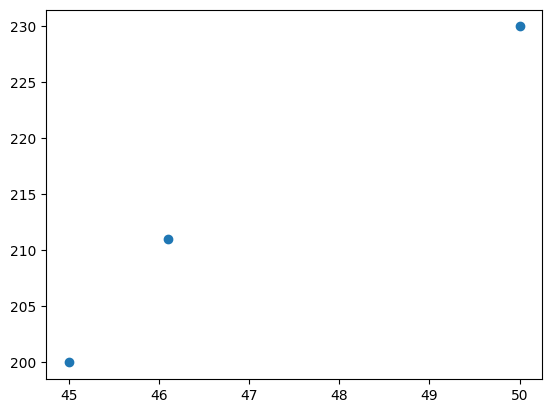

In [50]:
plt.scatter([46.1, 45, 50], [211, 200, 230])

## Задание 3. Ближайшие соседи

В этом задании ты реализуешь алгоритм 1-NN (k=1), где для каждой точки из 
тестовой выборки находится ближайший сосед из обучающей выборки, и класс 
этого соседа присваивается тестовой точке.

1. **Реализация поиска ближайшего соседа:**
   - Реализуй функцию `find_nearest_neighbor(test_point, train_data, 
   train_labels, distance_func)`, которая находит ближайшего соседа для 
   тестовой точки и возвращает метку его класса.

2. **Классификация тестовой выборки:**
   - Используй только признаки `culmen_length_mm` и `flipper_length_mm` для 
   классификации.
   - Для каждой точки из тестовой выборки найди ближайшего соседа из 
   обучающей выборки, используя евклидову метрику расстояния.
   - Определи класс для каждой тестовой точки на основе класса ее 
   ближайшего соседа.

3. **Оценка точности классификации:**
   - Посчитай точность классификации, сравнив предсказанные классы с 
   реальными метками тестовой выборки.
   - Выведи значение точности в процентах с округлением до 2 знаков после 
   запятой.

4. **Визуализация результатов:**
   - Построй график рассеяния с обучающей и тестовой выборками (используй 
   те же два признака, что и ранее: длина клюва и длина ласт).
   - Обучающая выборка: точки окрашены по реальным классам.
   - Тестовая выборка: точки окрашены по предсказанным классам.
   - Для каждой тестовой точки проведи линию к ее ближайшему соседу.
   - Добавь подписи осей, заголовок и легенду.

5. **Сравнение с sklearn:**
   - Используй `KNeighborsClassifier` из `sklearn.neighbors` с `n_neighbors=1` 
   для классификации тестовой выборки.
   - Сравни полученную точность с результатом своей реализации.

In [51]:
def find_nearest_neighbor(test_point, train_data):
    x = 'culmen_length_mm'
    y = 'flipper_length_mm'
    label = 'species'
    answer = ''
    min_len = float('inf')
    for idx in train_data.index:
        p = train_data.loc[idx]
        f = euclidean_distance([test_point[x], test_point[y]], [p[x], p[y]])
        if f <= min_len:
            answer = p[label]
            min_len = f
    return answer


In [52]:
pred = []

for idx in test.index:
    pred.append(find_nearest_neighbor(test.loc[idx], train))

p = test.copy()
p['pred'] = pred

In [53]:
accuracy = (p['pred'] == p['species']).sum() / len(p)

print(f"Точность: {accuracy:.2%}")

Точность: 95.05%


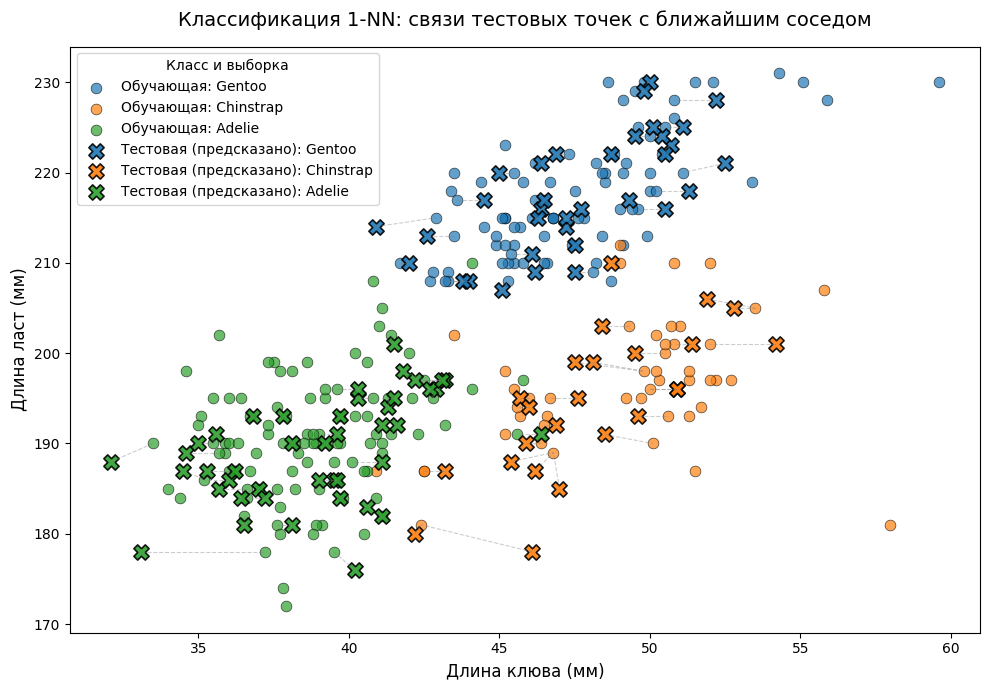

In [54]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Определяем координаты ближайшего соседа для каждой тестовой точки
# -----------------------------
nearest_x = []
nearest_y = []

for idx in test.index:
    tp = test.loc[idx]                     # тестовая точка
    min_dist = float('inf')
    nearest_idx = None
    for t_idx in train.index:
        tr = train.loc[t_idx]              # точка обучающей выборки
        d = euclidean_distance(
            [tp['culmen_length_mm'], tp['flipper_length_mm']],
            [tr['culmen_length_mm'], tr['flipper_length_mm']]
        )
        if d < min_dist:
            min_dist = d
            nearest_idx = t_idx
    # координаты ближайшего соседа
    n = train.loc[nearest_idx]
    nearest_x.append(n['culmen_length_mm'])
    nearest_y.append(n['flipper_length_mm'])

# -----------------------------
# 2. Готовим цвета для классов
# -----------------------------
# Убедимся, что используем все возможные классы (из train и p)
all_species = list(set(train['species'].unique()) | set(p['pred'].unique()))
# Простой список цветов (можно заменить на любые)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_map = {sp: colors[i % len(colors)] for i, sp in enumerate(all_species)}

# -----------------------------
# 3. Строим график
# -----------------------------
plt.figure(figsize=(10, 7))

# Обучающая выборка – кружки
for sp in all_species:
    mask = train['species'] == sp
    if mask.any():
        plt.scatter(
            train.loc[mask, 'culmen_length_mm'],
            train.loc[mask, 'flipper_length_mm'],
            color=color_map[sp],
            marker='o', s=60, alpha=0.7,
            edgecolors='black', linewidth=0.5,
            label=f'Обучающая: {sp}'
        )

# Тестовая выборка – крестики
for sp in all_species:
    mask = p['pred'] == sp
    if mask.any():
        plt.scatter(
            p.loc[mask, 'culmen_length_mm'],
            p.loc[mask, 'flipper_length_mm'],
            color=color_map[sp],
            marker='X', s=120, alpha=0.9,
            edgecolors='black', linewidth=1.2,
            label=f'Тестовая (предсказано): {sp}'
        )

# Линии от тестовых точек к ближайшим соседям
for i in range(len(test)):
    plt.plot(
        [test.iloc[i]['culmen_length_mm'], nearest_x[i]],
        [test.iloc[i]['flipper_length_mm'], nearest_y[i]],
        color='gray', alpha=0.4, linewidth=0.8, linestyle='--'
    )

# Подписи и оформление
plt.xlabel('Длина клюва (мм)', fontsize=12)
plt.ylabel('Длина ласт (мм)', fontsize=12)
plt.title('Классификация 1-NN: связи тестовых точек с ближайшим соседом', fontsize=14, pad=15)

# Чистая легенда без дубликатов
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), 
           title='Класс и выборка', loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [55]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
train['species'] = enc.fit_transform(train['species'])
test['species'] = enc.transform(test['species'])

In [56]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(
    n_neighbors=1,
)

model.fit(train[['culmen_length_mm','flipper_length_mm']], train['species'])
predict = model.predict(test[['culmen_length_mm','flipper_length_mm']])

from sklearn.metrics import accuracy_score

accuracy_score(test['species'], predict)


0.9504950495049505

## Задание 4. Больше соседей

В предыдущем задании ты использовал алгоритм 1-NN (k=1), где для классификации 
брал только одного ближайшего соседа. Теперь ты изучишь, как изменение 
количества соседей влияет на качество классификации. Это важный шаг в 
понимании того, как параметр k влияет на переобучение и недообучение модели.

1. **Исследование влияния количества соседей:**
   - Используй `KNeighborsClassifier` из `sklearn.neighbors` для классификации.
   - Проверь количество соседей от 1 до 30 включительно (k от 1 до 30).
   - Для каждого значения k обучи классификатор на обучающей выборке и 
   вычисли точность на обучающей и тестовой выборках.
   - Сохрани результаты в два списка: один для точности на обучающей выборке, 
   другой для точности на тестовой выборке.

2. **Визуализация зависимости точности от количества соседей:**
   - Построй график, на котором по оси X отложено количество соседей (k), а 
   по оси Y — точность классификации.
   - На графике должны быть две линии:
     - Линия для точности на обучающей выборке (train accuracy).
     - Линия для точности на тестовой выборке (test accuracy).
   - Используй разные цвета и маркеры для каждой линии.
   - Добавь подписи осей, заголовок графика и легенду.
   - Добавь сетку для удобства чтения значений.

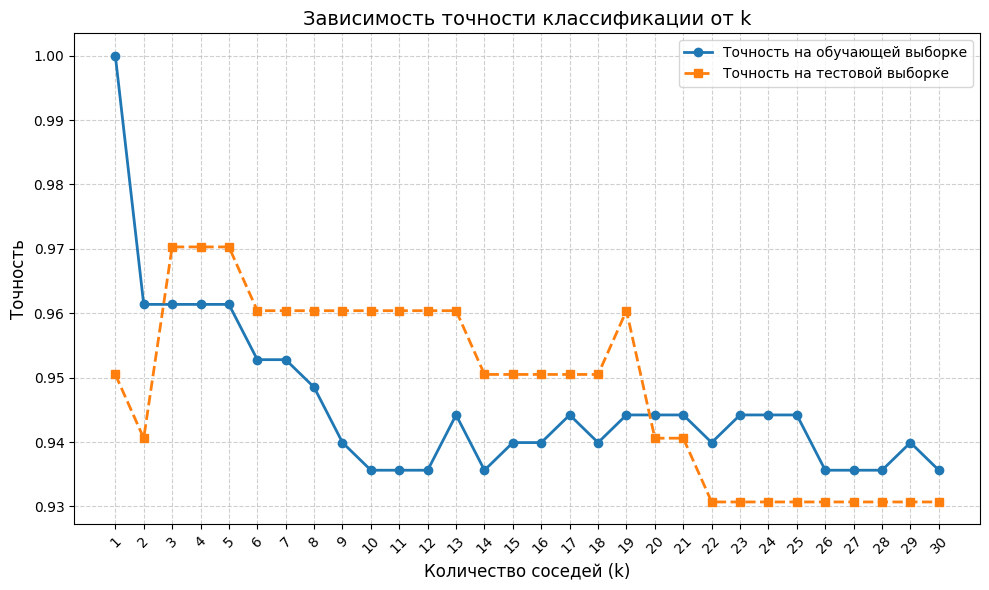

In [57]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Признаки и целевая переменная
X_train = train[['culmen_length_mm', 'flipper_length_mm']]
y_train = train['species']
X_test  = test[['culmen_length_mm', 'flipper_length_mm']]
y_test  = test['species']

k_values = range(1, 31)
train_acc = []
test_acc  = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    # точность на обучающей выборке
    pred_train = model.predict(X_train)
    train_acc.append(accuracy_score(y_train, pred_train))
    
    # точность на тестовой выборке
    pred_test = model.predict(X_test)
    test_acc.append(accuracy_score(y_test, pred_test))

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_acc, 'o-', color='#1f77b4', linewidth=2, markersize=6,
         label='Точность на обучающей выборке')
plt.plot(k_values, test_acc, 's--', color='#ff7f0e', linewidth=2, markersize=6,
         label='Точность на тестовой выборке')

plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('Точность', fontsize=12)
plt.title('Зависимость точности классификации от k', fontsize=14)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_values, rotation=45)
plt.tight_layout()
plt.show()

## Задание 5. Стандартизация признаков

В предыдущих заданиях ты работал с признаками, которые имели схожие масштабы 
(длина клюва и длина ласт измеряются в миллиметрах). Однако в реальных задачах 
признаки часто имеют разные единицы измерения и масштабы. Например, масса тела 
пингвина измеряется в граммах (значения порядка тысяч), а длина клюва — в 
миллиметрах (значения порядка десятков).

Когда признаки имеют разные масштабы, метрики расстояния (например, евклидова 
метрика) будут в основном определяться признаком с большими значениями. Это 
может привести к тому, что важные закономерности в признаках с меньшими 
значениями будут проигнорированы, что негативно скажется на качестве 
классификации.

![Стандартизация](../misc/images/standardization.png)

**Стандартизация** — это процесс преобразования признаков таким образом, чтобы 
они имели нулевое среднее значение и единичную дисперсию. Это позволяет всем 
признакам вносить равный вклад в вычисление расстояний, независимо от их 
исходных масштабов.

1. **Работа с признаками разного масштаба:**
   - Используй признаки `body_mass_g` (масса тела) и `culmen_length_mm` 
   (длина клюва) для классификации.
   - Обучи модель k-NN на этих признаках с параметром k=3.
   - Вычисли точность классификации на тестовой выборке.
   - Визуализируй данные в пространстве этих признаков: построй график 
   рассеяния с обучающей и тестовой выборками, где точки окрашены по классам.

2. **Анализ проблемы масштабов:**
   - Выведи статистику по признакам (среднее, стандартное отклонение, минимум, 
   максимум) для обучающей выборки.
   - Объясни, почему признаки с разными масштабами могут создавать проблемы 
   для метрических алгоритмов.

3. **Применение стандартизации:**
   - Используй `StandardScaler` из `sklearn.preprocessing` для стандартизации 
   признаков.
   - Примени `fit_transform` к обучающей выборке и `transform` к тестовой 
   выборке (важно: стандартизация должна быть обучена только на обучающих 
   данных!).
   - Выведи среднее значение и дисперсию стандартизированных признаков для 
   обучающей выборки.
   - Убедись, что среднее значение близко к 0, а дисперсия близка к 1 для 
   каждого признака.

4. **Переобучение модели на стандартизированных данных:**
   - Обучи модель k-NN на стандартизированных признаках с параметром k=3.
   - Вычисли точность классификации на тестовой выборке.
   - Сравни точность до и после стандартизации.
   - Визуализируй стандартизированные данные: построй график рассеяния с 
   обучающей и тестовой выборками.

5. **Сравнение результатов:**
   - Сравни визуально графики до и после стандартизации: как изменилось 
   распределение точек в пространстве признаков?

In [58]:
df['body_mass_g'].describe()

count     334.000000
mean     4209.056886
std       804.836129
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4793.750000
max      6300.000000
Name: body_mass_g, dtype: float64

In [59]:
df['culmen_length_mm'].describe()

count    334.000000
mean      43.994311
std        5.460521
min       32.100000
25%       39.500000
50%       44.500000
75%       48.575000
max       59.600000
Name: culmen_length_mm, dtype: float64

Признаки с большем значением воспринимаются как более важные для моделей.


In [60]:
X = df[['body_mass_g','culmen_length_mm']]
y = df['species']

enc = LabelEncoder()
y = enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    shuffle=True,
    random_state=42
)

model = KNeighborsClassifier(
    n_neighbors=3
)

model.fit(X_train, y_train)
predict = model.predict(X_test)

accuracy_score(y_test, predict)

0.7425742574257426

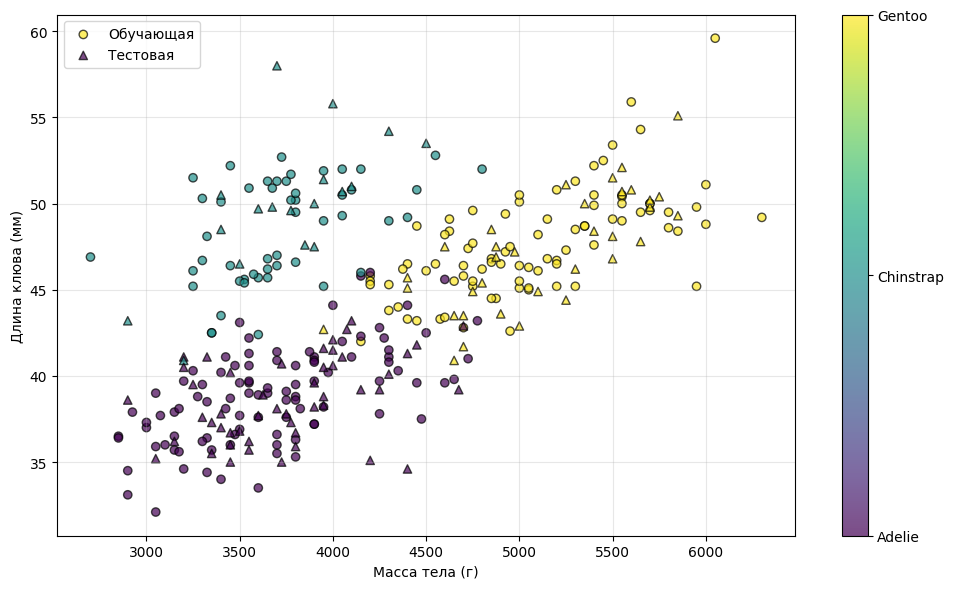

In [61]:
# --- Визуализация ---
plt.figure(figsize=(10, 6))

# Обучающая выборка: кружки
scatter_train = plt.scatter(X_train['body_mass_g'], X_train['culmen_length_mm'],
                            c=y_train, cmap='viridis', marker='o', edgecolors='k',
                            alpha=0.7, label='Обучающая')

# Тестовая выборка: треугольники
scatter_test = plt.scatter(X_test['body_mass_g'], X_test['culmen_length_mm'],
                           c=y_test, cmap='viridis', marker='^', edgecolors='k',
                           alpha=0.7, label='Тестовая')

# Настройка цветовой шкалы (классы)
classes = enc.classes_  # исходные названия видов
cbar = plt.colorbar(scatter_train, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(classes)

plt.xlabel('Масса тела (г)')
plt.ylabel('Длина клюва (мм)')
plt.legend(handles=[scatter_train, scatter_test], loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [63]:
import numpy as np
print("=== Обучающая выборка ===")
print(f"Среднее: {np.mean(X_train_scaled, axis=0)}")
print(f"Дисперсия: {np.var(X_train_scaled, axis=0)}")

print("\n=== Тестовая выборка ===")
print(f"Среднее: {np.mean(X_test_scaled, axis=0)}")
print(f"Дисперсия: {np.var(X_test_scaled, axis=0)}")

=== Обучающая выборка ===
Среднее: [-4.95550191e-17 -8.09557476e-16]
Дисперсия: [1. 1.]

=== Тестовая выборка ===
Среднее: [ 0.01979401 -0.12318817]
Дисперсия: [0.91594766 1.14848256]


In [64]:
model = KNeighborsClassifier(
    n_neighbors=3
)

model.fit(X_train_scaled, y_train)
predict = model.predict(X_test_scaled)

accuracy_score(y_test, predict)

0.9504950495049505

Точность на тестовой выборке (после масштабирования): 0.950


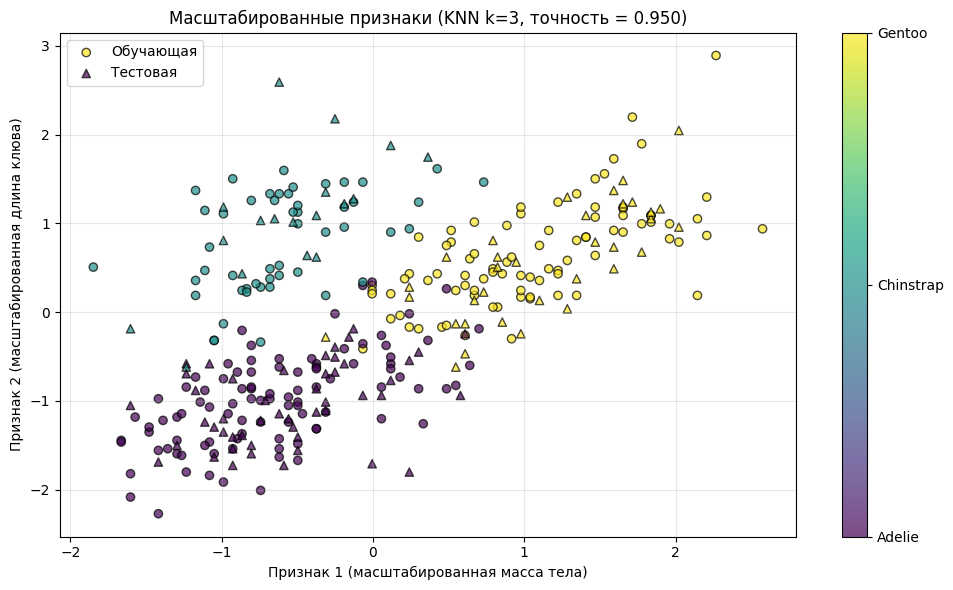

In [65]:
acc = accuracy_score(y_test, predict)
print(f"Точность на тестовой выборке (после масштабирования): {acc:.3f}")

# --- Визуализация ---
plt.figure(figsize=(10, 6))

# Обучающая выборка: кружки (marker='o')
scatter_train = plt.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1],
    c=y_train, cmap='viridis', marker='o', edgecolors='k', alpha=0.7,
    label='Обучающая'
)

# Тестовая выборка: треугольники (marker='^')
scatter_test = plt.scatter(
    X_test_scaled[:, 0], X_test_scaled[:, 1],
    c=y_test, cmap='viridis', marker='^', edgecolors='k', alpha=0.7,
    label='Тестовая'
)

# Настройка цветовой шкалы (подписи классов)
classes = enc.classes_  # исходные названия видов пингвинов
cbar = plt.colorbar(scatter_train, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(classes)

plt.xlabel('Признак 1 (масштабированная масса тела)')
plt.ylabel('Признак 2 (масштабированная длина клюва)')
plt.title(f'Масштабированные признаки (KNN k=3, точность = {acc:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Вывод: улучшилась точность


## Задание 6. Кросс-валидация

В предыдущих заданиях ты использовал фиксированное разделение данных на 
обучающую и тестовую выборки. Однако такой подход имеет ограничения: результат 
может сильно зависеть от того, как именно были разделены данные. Кроме того, 
при подборе гиперпараметров (таких как количество соседей k в алгоритме k-NN) 
использование тестовой выборки для оценки качества может привести к 
переобучению на тестовых данных.

**Гиперпараметр** — это параметр алгоритма, который задается до начала обучения 
и не изменяется в процессе обучения. В алгоритме k-NN гиперпараметром является 
количество соседей k. Правильный выбор гиперпараметра критически важен для 
качества модели: слишком маленькое k может привести к переобучению (модель 
запоминает шум в данных), а слишком большое — к недообучению (модель становится 
слишком простой и не учитывает локальные закономерности).

**K-fold кросс-валидация** — это метод оценки качества модели, при котором 
данные разбиваются на k частей (фолдов). Модель обучается k раз: каждый раз 
одна из частей используется как валидационная выборка, а остальные k-1 частей — 
как обучающая. В результате получается k оценок качества, которые можно 
усреднить для получения более надежной оценки.

![K-Fold](../misc/images/k_fold.png)


1. **Реализация k-fold кросс-валидации:**
   - Используй `cross_val_score` из `sklearn.model_selection` для проведения 
   кросс-валидации.
   - Проверь значения k от 1 до 30 включительно.
   - Используй 5-fold кросс-валидацию (cv=5).
   - Для каждого значения k вычисли среднюю точность и стандартное отклонение 
   по всем фолдам.

2. **Визуализация результатов кросс-валидации:**
   - Построй график, на котором по оси X отложено количество соседей (k), а по 
   оси Y — средняя точность классификации.
   - Добавь на график область, показывающую стандартное отклонение используй `fill_between`.
   - Добавь подписи осей, заголовок графика и легенду.
   - Добавь сетку для удобства чтения значений.

3. **Выбор оптимального гиперпараметра:**
   - Определи оптимальное значение k на основе результатов кросс-валидации 
   (значение с максимальной средней точностью).
   - Выведи оптимальное значение k и соответствующую ему среднюю точность.

In [66]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

mean_score = []
std_score = []

for k in range(1,31):
    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')

    mean_score.append(score.mean())
    std_score.append(score.std())



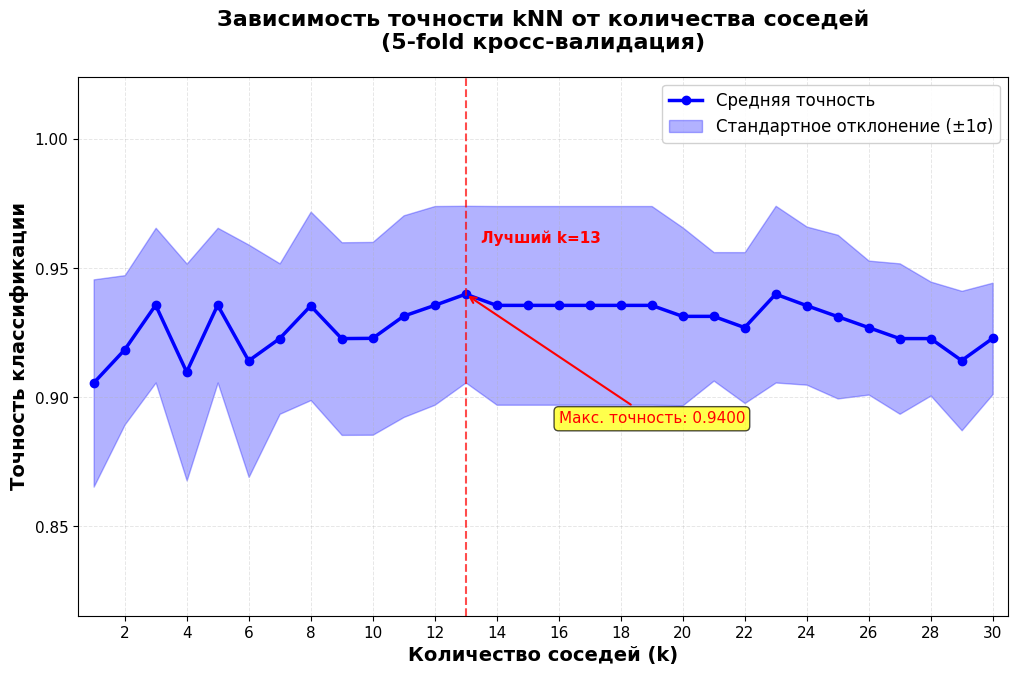

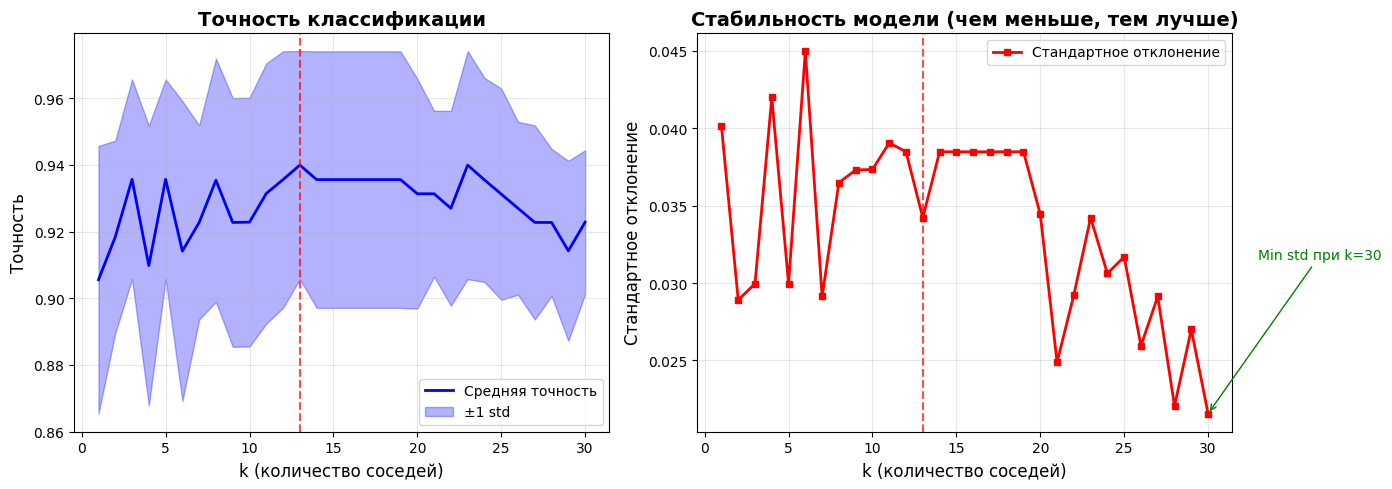


РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ
Лучшее значение k: 13
Максимальная средняя точность: 0.9400
Стандартное отклонение при k=13: 0.0342
Минимальное стандартное отклонение: 0.0216 при k=30

📊 РЕКОМЕНДАЦИЯ:
⚠️  k=13 показывает высокую точность, но нестабилен
💡 Рассмотрите k=30 для более стабильной модели


In [67]:
# Преобразование в numpy массивы для удобства
mean_score = np.array(mean_score)
std_score = np.array(std_score)
k_values = np.arange(1, 31)

# СОЗДАНИЕ ГРАФИКА
plt.figure(figsize=(12, 7))

# Основная линия - средняя точность
plt.plot(k_values, mean_score, 'b-', linewidth=2.5, label='Средняя точность', marker='o', markersize=6)

# Область стандартного отклонения (fill_between)
plt.fill_between(k_values, 
                 mean_score - std_score, 
                 mean_score + std_score, 
                 alpha=0.3, 
                 color='blue',
                 label='Стандартное отклонение (±1σ)')

# Настройка внешнего вида графика
plt.xlabel('Количество соседей (k)', fontsize=14, fontweight='bold')
plt.ylabel('Точность классификации', fontsize=14, fontweight='bold')
plt.title('Зависимость точности kNN от количества соседей\n(5-fold кросс-валидация)', 
          fontsize=16, fontweight='bold', pad=20)

# Добавление сетки
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Легенда
plt.legend(loc='best', fontsize=12, framealpha=0.9)

# Настройка осей
plt.xticks(np.arange(0, 31, 2), fontsize=11)  # шаг 2 для читаемости
plt.yticks(np.arange(0.5, 1.05, 0.05), fontsize=11)
plt.xlim(0.5, 30.5)
plt.ylim(min(mean_score - std_score) - 0.05, max(mean_score + std_score) + 0.05)

# Добавление вертикальной линии в точке лучшего k
best_k = k_values[np.argmax(mean_score)]
best_score = np.max(mean_score)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(best_k + 0.5, best_score + 0.02, f'Лучший k={best_k}', 
         fontsize=11, color='red', fontweight='bold')

# Добавление аннотации с максимальной точностью
plt.annotate(f'Макс. точность: {best_score:.4f}',
             xy=(best_k, best_score),
             xytext=(best_k + 3, best_score - 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11,
             color='red',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Дополнительный график: сравнение точности и стабильности
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Средняя точность с доверительным интервалом
ax1.plot(k_values, mean_score, 'b-', linewidth=2, label='Средняя точность')
ax1.fill_between(k_values, mean_score - std_score, mean_score + std_score, 
                 alpha=0.3, color='blue', label='±1 std')
ax1.set_xlabel('k (количество соседей)', fontsize=12)
ax1.set_ylabel('Точность', fontsize=12)
ax1.set_title('Точность классификации', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axvline(x=best_k, color='red', linestyle='--', alpha=0.7)

# График 2: Стандартное отклонение (стабильность модели)
ax2.plot(k_values, std_score, 'r-s', linewidth=2, markersize=5, label='Стандартное отклонение')
ax2.set_xlabel('k (количество соседей)', fontsize=12)
ax2.set_ylabel('Стандартное отклонение', fontsize=12)
ax2.set_title('Стабильность модели (чем меньше, тем лучше)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.7)

# Находим k с минимальным стандартным отклонением
min_std_k = k_values[np.argmin(std_score)]
ax2.annotate(f'Min std при k={min_std_k}', 
             xy=(min_std_k, np.min(std_score)),
             xytext=(min_std_k + 3, np.min(std_score) + 0.01),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10,
             color='green')

plt.tight_layout()
plt.show()

# Вывод статистики
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
print("="*60)
print(f"Лучшее значение k: {best_k}")
print(f"Максимальная средняя точность: {best_score:.4f}")
print(f"Стандартное отклонение при k={best_k}: {std_score[best_k-1]:.4f}")
print(f"Минимальное стандартное отклонение: {np.min(std_score):.4f} при k={min_std_k}")
print("="*60)

# Рекомендация
print("\n📊 РЕКОМЕНДАЦИЯ:")
if std_score[best_k-1] <= np.mean(std_score):
    print(f"✅ k={best_k} является хорошим выбором - высокая точность и низкая вариативность")
else:
    print(f"⚠️  k={best_k} показывает высокую точность, но нестабилен")
    print(f"💡 Рассмотрите k={min_std_k} для более стабильной модели")

# Проблемы K-NN и проклятье размерности

Метрические алгоритмы, такие как k-NN, имеют множество преимуществ: они просты 
в понимании и реализации, не требуют явного обучения модели, хорошо работают 
с нелинейными зависимостями и легко адаптируются к новым данным. Однако у них 
есть и существенные ограничения.

Одной из главных проблем метрических алгоритмов является **проклятье 
размерности** (curse of dimensionality). С увеличением количества признаков 
объем пространства признаков растет экспоненциально, и данные становятся 
все более разреженными. В результате расстояния между точками становятся 
похожими друг на друга, что делает метрики расстояния менее информативными 
для классификации.

В этом разделе ты изучишь, как проклятье размерности влияет на качество 
классификации k-NN, и познакомишься с методом уменьшения размерности — 
анализом главных компонент (PCA), который позволяет уменьшить эту проблему.

![curse](../misc/images/curse.png)

## Задание 7. Генерация выборки

Для демонстрации проклятья размерности сгенерируй синтетический датасет с 
различным количеством признаков и проанализируй, как это влияет на качество 
классификации.

1. **Генерация данных:**
   - Используй `make_classification` из `sklearn.datasets` для генерации 
   датасета с 3 классами, 10000 образцами и различным количеством признаков: 
   от 10 до 100. Количество информативных признаков — 5.
   - Для каждого количества признаков раздели данные на обучающую (75%) и 
   тестовую (25%) выборки с `random_state=42`.

2. **Обучение и оценка:**
   - Для каждого количества признаков обучи модель k-NN с параметрами 
   `k=5` и `metric="euclidean"`.
   - Вычисли точность классификации на тестовой выборке и сохрани результаты 
   (количество признаков и соответствующая точность).

In [68]:
from sklearn.datasets import make_classification

answer = []
all_data = []


for k in range(10,101,10):
    data = make_classification(n_samples=10_000, n_features=k, n_classes=3, n_informative=5)

    X_train, X_test, y_train, y_test = train_test_split(
        data[0], data[1],
        random_state=42,
        shuffle=True,
        test_size=0.25
    )

    all_data.append([X_train, X_test, y_train, y_test, k])

    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric='euclidean'
    )

    knn.fit(X_train, y_train)
    predict = knn.predict(X_test)

    answer.append([k, accuracy_score(y_test, predict)])

In [69]:
answer

[[10, 0.8836],
 [20, 0.83],
 [30, 0.816],
 [40, 0.71],
 [50, 0.7212],
 [60, 0.6488],
 [70, 0.7628],
 [80, 0.6668],
 [90, 0.7208],
 [100, 0.6804]]

## Задание 8. Проклятье размерности

Теперь визуализируй, как качество классификации изменяется с ростом 
количества признаков.

1. **Визуализация зависимости точности от размерности:**
   - Построй график, на котором по оси X отложено количество признаков, а 
   по оси Y — точность классификации на тестовой выборке.
   - Добавь подписи осей, заголовок графика и сетку.
   - Проанализируй график: как изменяется точность с увеличением количества 
   признаков?

2. **Анализ результатов:**
   - Определи размерность, при которой точность максимальна.
   - Объясни, почему точность сначала может расти (больше информации), а затем 
   падать (проклятье размерности).
   - Опиши, что такое проклятье размерности и почему оно возникает в 
   метрических алгоритмах.
   - Объясни, почему расстояния между точками становятся похожими при высокой 
   размерности.

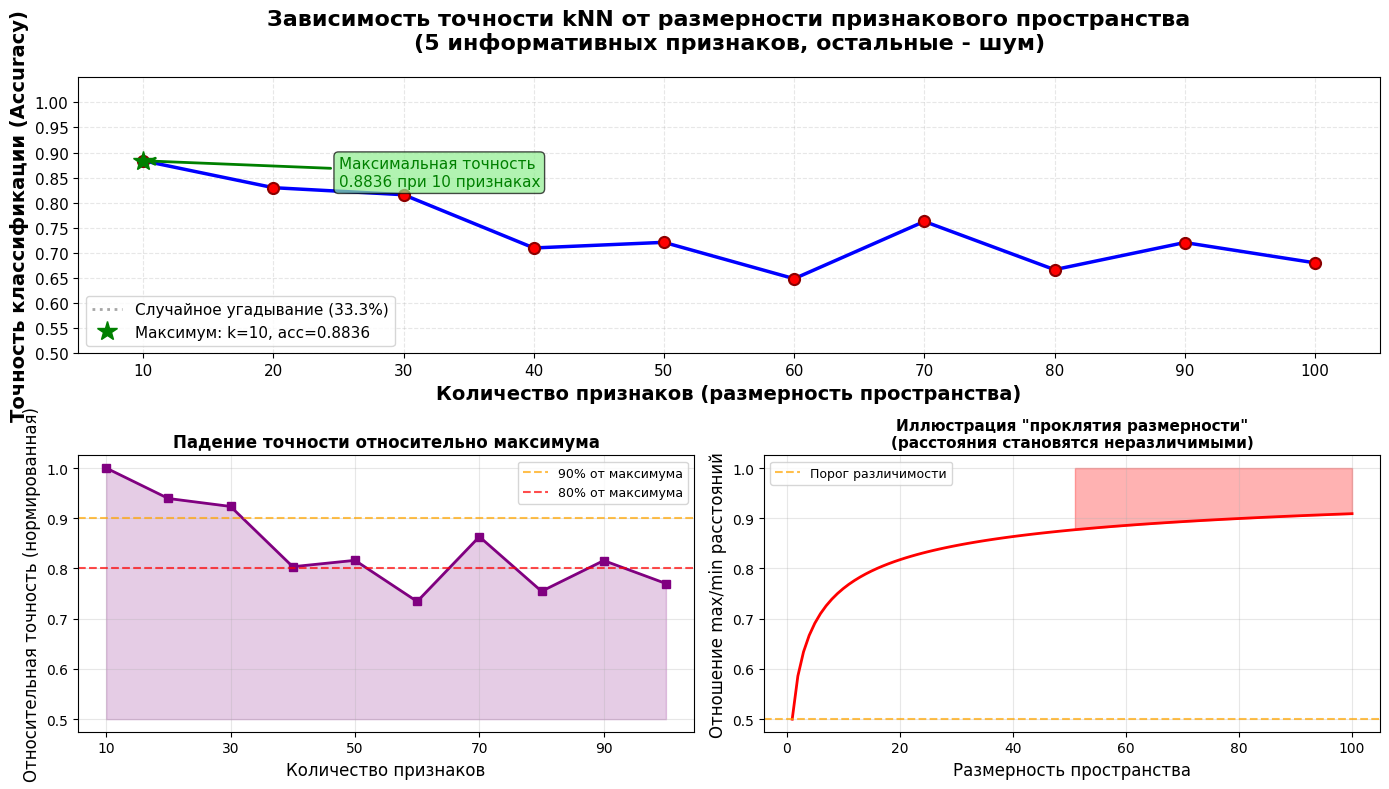


РЕЗУЛЬТАТЫ АНАЛИЗА ЗАВИСИМОСТИ ТОЧНОСТИ ОТ РАЗМЕРНОСТИ

📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
   • Максимальная точность: 0.8836 при 10 признаках
   • Точность при 10 признаках: 0.8836
   • Точность при 100 признаках: 0.6804
   • Падение точности: 0.2032 (23.0%)

📈 ДИНАМИКА ИЗМЕНЕНИЯ:
   10 → 20 признаков: ↓ падает на 0.0536
   20 → 30 признаков: ↓ падает на 0.0140
   30 → 40 признаков: ↓ падает на 0.1060
   40 → 50 признаков: ↑ растет на 0.0112
   50 → 60 признаков: ↓ падает на 0.0724
   60 → 70 признаков: ↑ растет на 0.1140
   70 → 80 признаков: ↓ падает на 0.0960
   80 → 90 признаков: ↑ растет на 0.0540
   90 → 100 признаков: ↓ падает на 0.0404

ТЕОРЕТИЧЕСКИЙ АНАЛИЗ

🔍 ПОЧЕМУ ТОЧНОСТЬ СНАЧАЛА РАСТЕТ, А ЗАТЕМ ПАДАЕТ?

1. ЭТАП РОСТА ТОЧНОСТИ (малая размерность):
   • При добавлении признаков (до ~20-30) модель получает больше информации
   • Объекты разных классов становятся лучше различимыми
   • Информативные признаки помогают точнее разделять классы

2. ЭТАП ПАДЕНИЯ ТОЧНОСТИ (высокая размерность

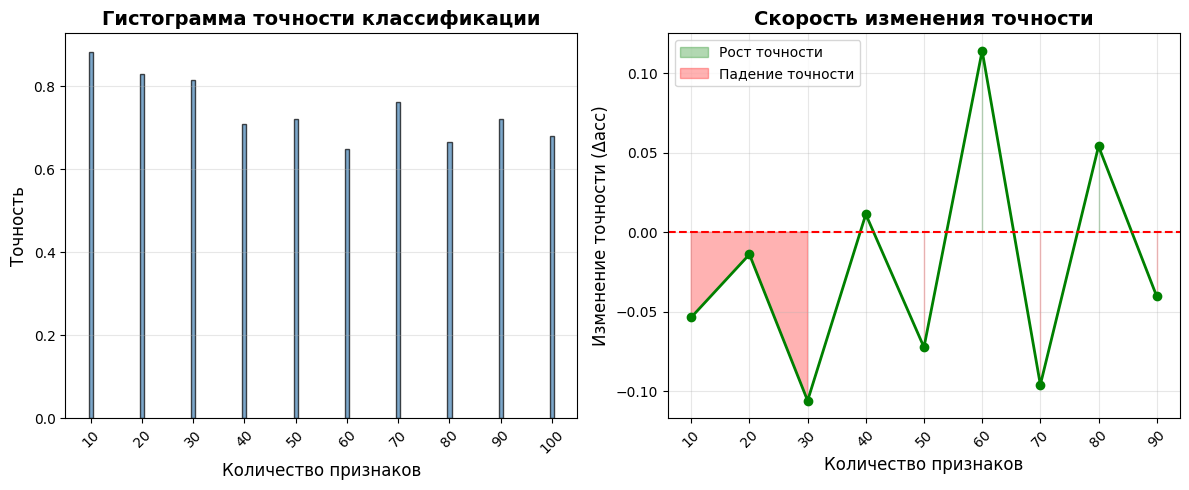

In [70]:

answer = np.array(answer)
plt.figure(figsize=(14, 8))

# Основной график
plt.subplot(2, 2, (1, 2))
plt.plot(answer[:, 0], answer[:, 1], 'b-o', linewidth=2.5, markersize=8, 
         markerfacecolor='red', markeredgecolor='darkred', markeredgewidth=1.5)
plt.xlabel('Количество признаков (размерность пространства)', fontsize=14, fontweight='bold')
plt.ylabel('Точность классификации (Accuracy)', fontsize=14, fontweight='bold')
plt.title('Зависимость точности kNN от размерности признакового пространства\n(5 информативных признаков, остальные - шум)', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.xticks(answer[:, 0], fontsize=11)
plt.yticks(np.arange(0.5, 1.05, 0.05), fontsize=11)
plt.ylim(0.5, 1.05)
plt.xlim(5, 105)

# Добавление горизонтальной линии - случайное угадывание
plt.axhline(y=1/3, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Случайное угадывание (33.3%)')

# Отметка максимальной точности
max_idx = np.argmax(answer[:, 1])
max_k = int(answer[max_idx, 0])
max_acc = answer[max_idx, 1]
plt.plot(max_k, max_acc, 'g*', markersize=15, label=f'Максимум: k={max_k}, acc={max_acc:.4f}')
plt.annotate(f'Максимальная точность\n{max_acc:.4f} при {max_k} признаках',
             xy=(max_k, max_acc),
             xytext=(max_k + 15, max_acc - 0.05),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=11,
             color='green',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()

# ============================================
# 2. ГРАФИКИ ДЛЯ ПОНИМАНИЯ ПРОКЛЯТИЯ РАЗМЕРНОСТИ
# ============================================

# Второй график: скорость падения точности
plt.subplot(2, 2, 3)
# Нормализованная точность относительно максимума
normalized_acc = answer[:, 1] / max_acc
plt.plot(answer[:, 0], normalized_acc, 'purple', linewidth=2, marker='s', markersize=6)
plt.fill_between(answer[:, 0], normalized_acc, 0.5, alpha=0.2, color='purple')
plt.xlabel('Количество признаков', fontsize=12)
plt.ylabel('Относительная точность (нормированная)', fontsize=12)
plt.title('Падение точности относительно максимума', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% от максимума')
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='80% от максимума')
plt.legend(fontsize=9)
plt.xticks(answer[:, 0][::2])

# Третий график: теоретическая иллюстрация "проклятия размерности"
plt.subplot(2, 2, 4)

# Теоретическая модель: как меняется отношение расстояний
dimensions = np.arange(1, 101)
# В многомерном пространстве отношение max/min расстояний стремится к 1
ratio = 1 - 1/(np.sqrt(dimensions) + 1)

plt.plot(dimensions, ratio, 'r-', linewidth=2)
plt.xlabel('Размерность пространства', fontsize=12)
plt.ylabel('Отношение max/min расстояний', fontsize=12)
plt.title('Иллюстрация "проклятия размерности"\n(расстояния становятся неразличимыми)', 
          fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Порог различимости')
plt.legend(fontsize=9)
plt.fill_between(dimensions[50:], ratio[50:], 1, alpha=0.3, color='red', label='Зона проклятия')

plt.tight_layout()
plt.show()

# ============================================
# 3. АНАЛИЗ РЕЗУЛЬТАТОВ
# ============================================

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ АНАЛИЗА ЗАВИСИМОСТИ ТОЧНОСТИ ОТ РАЗМЕРНОСТИ")
print("="*70)

# Определение размерности с максимальной точностью
print(f"\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print(f"   • Максимальная точность: {max_acc:.4f} при {max_k} признаках")
print(f"   • Точность при 10 признаках: {answer[0, 1]:.4f}")
print(f"   • Точность при 100 признаках: {answer[-1, 1]:.4f}")
print(f"   • Падение точности: {answer[0, 1] - answer[-1, 1]:.4f} ({(1 - answer[-1,1]/answer[0,1])*100:.1f}%)")

# Определение точек перегиба
print(f"\n📈 ДИНАМИКА ИЗМЕНЕНИЯ:")
for i in range(1, len(answer)):
    delta = answer[i, 1] - answer[i-1, 1]
    trend = "↑ растет" if delta > 0 else "↓ падает" if delta < 0 else "→ стабильна"
    print(f"   {int(answer[i-1, 0])} → {int(answer[i, 0])} признаков: {trend} на {abs(delta):.4f}")

print("\n" + "="*70)
print("ТЕОРЕТИЧЕСКИЙ АНАЛИЗ")
print("="*70)

print("""
🔍 ПОЧЕМУ ТОЧНОСТЬ СНАЧАЛА РАСТЕТ, А ЗАТЕМ ПАДАЕТ?

1. ЭТАП РОСТА ТОЧНОСТИ (малая размерность):
   • При добавлении признаков (до ~20-30) модель получает больше информации
   • Объекты разных классов становятся лучше различимыми
   • Информативные признаки помогают точнее разделять классы

2. ЭТАП ПАДЕНИЯ ТОЧНОСТИ (высокая размерность):
   • После превышения оптимальной размерности начинается "проклятие размерности"
   • Добавляются шумовые признаки, которые не несут полезной информации
   • Расстояния между точками становятся менее информативными
   
📚 ЧТО ТАКОЕ "ПРОКЛЯТИЕ РАЗМЕРНОСТИ"?

Проклятие размерности — это явление, при котором с ростом размерности 
пространства метрические алгоритмы (включая kNN) теряют эффективность.

Почему это происходит в метрических алгоритмах:
• kNN основан на вычислении расстояний между точками
• В многомерном пространстве все расстояния становятся примерно одинаковыми
• Трудно определить, какие точки действительно "близкие", а какие "далекие"
• Для сохранения плотности точек нужно экспоненциально больше данных

📐 ПОЧЕМУ РАССТОЯНИЯ СТАНОВЯТСЯ ПОХОЖИМИ?

Математическое объяснение:
• В d-мерном пространстве объем гиперсферы растет как r^d
• Доля точек внутри сферы фиксированного радиуса стремится к 0
• Расстояние от произвольной точки до ближайшего соседа стремится 
  к расстоянию до самого дальнего соседа

Пример для евклидова расстояния:
• В 1D: точки могут быть очень близко или очень далеко
• В 100D: все пары точек имеют примерно одинаковое расстояние

Для kNN это означает:
• Нельзя выделить истинных "соседей"
• Все объекты равноудалены друг от друга
• Классификация становится близкой к случайному угадыванию
""")

print("="*70)
print("💡 ПРАКТИЧЕСКИЕ ВЫВОДЫ:")
print(f"   • Оптимальное количество признаков для этой задачи: {max_k}")
print("   • Рекомендуется использовать методы снижения размерности (PCA)")
print("   • При работе с kNN важно отбирать информативные признаки")
print("   • Альтернатива: использование метрик, устойчивых к высокой размерности")
print("="*70)

# Дополнительная визуализация: сравнение с теоретической моделью
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(answer[:, 0], answer[:, 1], color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Количество признаков', fontsize=12)
plt.ylabel('Точность', fontsize=12)
plt.title('Гистограмма точности классификации', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(answer[:, 0], rotation=45)

plt.subplot(1, 2, 2)
# Скорость изменения точности
derivative = np.diff(answer[:, 1])
plt.plot(answer[:-1, 0], derivative, 'g-o', linewidth=2, markersize=6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.fill_between(answer[:-1, 0], derivative, 0, where=(derivative > 0), 
                 color='green', alpha=0.3, label='Рост точности')
plt.fill_between(answer[:-1, 0], derivative, 0, where=(derivative < 0), 
                 color='red', alpha=0.3, label='Падение точности')
plt.xlabel('Количество признаков', fontsize=12)
plt.ylabel('Изменение точности (Δacc)', fontsize=12)
plt.title('Скорость изменения точности', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(answer[:-1, 0], rotation=45)

plt.tight_layout()
plt.show()

## Задание 9. Уменьшение размерности

Для решения проблемы проклятья используется уменьшение размерности. В этом задании ты применишь анализ главных компонент (PCA) для снижения размерности признакового пространства.

1. **Применение PCA для уменьшения размерности:**
   - Используй те же данные, что и в задании 7.
   - Для каждого количества признаков примени PCA из `sklearn.decomposition` с параметрами `n_components=10` и `random_state=42`.
   - Важно: обучи PCA только на обучающей выборке (`fit`), затем примени к обеим выборкам (`transform`).
   - Обучи модель k-NN на уменьшенных признаках с параметрами `k=5` и `metric="euclidean"`.
   - Вычисли точность классификации на тестовой выборке для каждого количества признаков.
   - Сохрани результаты: количество признаков и соответствующую точность модели.

2. **Визуализация результатов:**
   - Построй график зависимости точности от количества признаков (как в задании 8): сравни результаты с PCA и без него.
   - Сделай вывод о том, как PCA влияет на точность классификации.


In [71]:
from sklearn.decomposition import PCA

answer = []

for data in all_data:

    X_train, X_test, y_train, y_test, k = data

    pca = PCA(
        n_components=10,
        random_state=42
    )

    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric='euclidean'
    )

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    knn.fit(X_train_pca, y_train)
    predict = knn.predict(X_test_pca)
    accuracy = accuracy_score(y_test, predict)
    answer.append([k, accuracy])

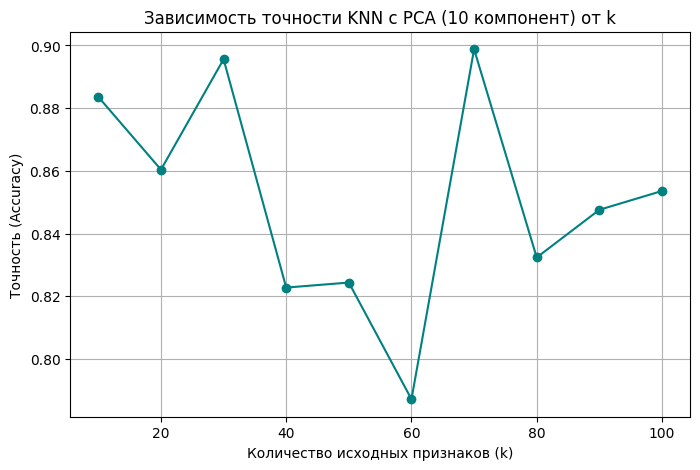

In [72]:
k_values = [item[0] for item in answer]
acc_values = [item[1] for item in answer]

plt.figure(figsize=(8, 5))
plt.plot(k_values, acc_values, marker='o', linestyle='-', color='teal')
plt.xlabel('Количество исходных признаков (k)')
plt.ylabel('Точность (Accuracy)')
plt.title('Зависимость точности KNN с PCA (10 компонент) от k')
plt.grid(True)
plt.show()

# Гибридный поиск фильмов

Алгоритмы поиска ближайших соседей активно используются в современных 
поисковых системах и рекомендательных сервисах. Когда ты ищешь фильм в 
онлайн-кинотеатре или товар в интернет-магазине, под капотом работают 
системы векторного поиска, которые находят похожие объекты по их 
семантическому сходству.

В реальных задачах поиска информации часто комбинируют классические 
алгоритмы (например, BM25, основанный на частоте терминов) и 
нейросетевые подходы (embeddings, полученные с помощью языковых моделей). 
Классические методы хорошо работают с точным совпадением ключевых слов, 
а нейросетевые модели лучше понимают семантику и синонимы. Гибридный 
поиск объединяет преимущества обоих подходов: он может находить 
релевантные результаты как по точному совпадению слов, так и по 
смысловому сходству.

В этом разделе ты реализуешь небольшой поисковый алгоритм для поиска 
фильмов, который будет использовать гибридный подход: комбинацию sparse-векторов (BM25) и dense-векторов (embeddings от языковых моделей). Это 
позволит тебе понять, как современные поисковые системы находят 
релевантную информацию и как можно комбинировать разные типы признаков 
для улучшения качества поиска.

![film](../misc/images/film_v1.png)


## Задание 10. Поиск по словам

В этом задании ты реализуешь поиск фильмов с использованием sparse 
векторов на основе алгоритма BM25. **Sparse-векторы** (разреженные векторы) 
— это векторы, в которых большинство элементов равны нулю. Они 
эффективно представляют текстовые документы, где каждая позиция 
соответствует определенному слову из словаря, а значение — частоте или 
важности этого слова в документе.

BM25 (Best Matching 25) — это классический алгоритм ранжирования в 
информационном поиске, который учитывает частоту терминов и обратную 
частоту документа. Он хорошо работает для точного поиска по ключевым 
словам и широко используется в поисковых системах.

1. **Загрузка и подготовка данных:**
   - Загрузи датасет с фильмами из файла `datasets/imdb_top_1000.csv` с 
   помощью библиотеки `pandas`.
   - Объедини название фильма (столбец `Series_Title`) и описание фильма 
   (столбец `Overview`) в единый текст. Создай новый столбец `text`, 
   который будет содержать объединенный текст в формате: «название 
   фильма. описание фильма».
   - Удали строки, где отсутствует значение в столбце `Overview` или 
   `Series_Title`.

2. **Создание коллекции в Qdrant:**
   - Установи и импортируй библиотеку [`qdrant-client`](https://github.com/qdrant/qdrant-client) для работы с векторной базой данных Qdrant. Qdrant — это векторная база данных, предназначенная для эффективного хранения и поиска по 
   многомерным векторам. Она позволяет хранить векторы вместе с 
   метаданными и выполнять быстрый поиск ближайших соседей, что 
   критически важно для задач семантического поиска и рекомендательных 
   систем.
   - Создай клиент Qdrant в режиме работы в памяти (in-memory mode).
   - Создай коллекцию с именем `movie_v1` для хранения векторов фильмов.
   - Настрой коллекцию для работы со sparse-векторами, используя модель 
   `Qdrant/bm25` для генерации векторов.

3. **Добавление данных в коллекцию:**
   - Для каждого фильма создай точку (point) в коллекции со следующими 
   параметрами:
     - `text` — объединенный текст (название и описание фильма);
     - `genre` — жанр фильма;
     - `rating` — рейтинг фильма;
     - `title` — название фильма.
   - Сгенерируй sparse-вектор для текста каждого фильма с помощью модели 
   `Qdrant/bm25`.
   - Добавь все точки в коллекцию `movie_v1`.

4. **Проверка коллекции:**
   - Выведи количество объектов в коллекции `movie_v1`.
   - Убедись, что количество объектов соответствует количеству фильмов в 
   датасете (после удаления строк с пропусками).

5. **Тестирование поиска:**
   - Выполни поиск по базе с запросом «superhero movie».
   - Выполни поиск по базе с запросом «thriller about a maniac».
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами и рейтингами.

In [89]:
import pandas as pd
import numpy as np
from qdrant_client import QdrantClient
from qdrant_client.http import models
from fastembed import SparseTextEmbedding

np.NINF = -np.inf

# Если возникает ошибка "np.NINF was removed", раскомментируй следующую строку:
# np.NINF = -np.inf

# --- 1. Загрузка данных ---
df = pd.read_csv("C://Users/User/Desktop/ml2/AI_Machine_Learning_Project_2.ID_1577772-1/datasets/imdb_top_1000.csv")
df = df.dropna(subset=['Series_Title', 'Overview'])
df['text'] = df['Series_Title'] + '. ' + df['Overview']

# --- 2. Инициализация BM25 ---
bm25_model = SparseTextEmbedding(model_name="Qdrant/bm25")

# --- 3. Создание клиента Qdrant и коллекции ---
client = QdrantClient(":memory:")
collection_name = "movie_v1"

if client.collection_exists(collection_name):
    client.delete_collection(collection_name)

client.create_collection(
    collection_name=collection_name,
    vectors_config={},
    sparse_vectors_config={
        "text": models.SparseVectorParams(
            index=models.SparseIndexParams(on_disk=False)
        )
    }
)

# --- 4. Индексация фильмов ---
all_texts = df['text'].tolist()
raw_vectors = list(bm25_model.embed(all_texts))   # здесь может вылететь np.NINF в старых fastembed

all_sparse_vectors = []
for vec in raw_vectors:
    # fastembed возвращает объекты SparseEmbedding (если версия >= 0.3.0)
    all_sparse_vectors.append(
        models.SparseVector(
            indices=vec.indices.tolist(),
            values=vec.values.tolist()
        )
    )

batch_size = 50
for i in range(0, len(df), batch_size):
    batch = df.iloc[i:i+batch_size]
    batch_vectors = all_sparse_vectors[i:i+batch_size]

    points = [
        models.PointStruct(
            id=int(idx),
            vector={"text": sv},
            payload={
                "title": batch.iloc[j]['Series_Title'],
                "genre": batch.iloc[j]['Genre'],
                "rating": float(batch.iloc[j]['IMDB_Rating']) if pd.notna(batch.iloc[j]['IMDB_Rating']) else 0.0,
                "text": batch.iloc[j]['text']
            }
        )
        for j, (idx, sv) in enumerate(zip(batch.index, batch_vectors))
    ]
    client.upsert(collection_name=collection_name, points=points)
    print(f"✓ Добавлено фильмов {min(i+batch_size, len(df))}/{len(df)}")

print(f"\nЗагрузка завершена! Фильмов в коллекции: {client.count(collection_name).count}")

# --- 5. Функция поиска и вывод результатов ---
def search_and_print(query_text, limit=5):
    print(f"\n{'='*60}")
    print(f"Запрос: \"{query_text}\"")
    print(f"{'='*60}")

    # Векторизуем запрос той же моделью
    query_embedding = list(bm25_model.embed([query_text]))[0]
    sparse_vec = models.SparseVector(
        indices=query_embedding.indices.tolist(),
        values=query_embedding.values.tolist()
    )

    results = client.search(
        collection_name=collection_name,
        query_vector=models.NamedSparseVector(name="text", vector=sparse_vec),
        limit=limit
    )

    print(f"\nТоп-{limit} фильмов:\n")
    print(f"{'№':<3} {'Название':<40} {'Жанр':<30} {'Рейтинг':>6}")
    print("-" * 80)
    for i, hit in enumerate(results, 1):
        title = hit.payload.get("title", "—")
        genre = hit.payload.get("genre", "—")
        rating = hit.payload.get("rating", 0.0)
        print(f"{i:<3} {title:<40} {genre:<30} {rating:>6.1f}")

# --- 6. Выполняем поиск ---
search_and_print("superhero movie")
search_and_print("thriller about a maniac")

✓ Добавлено фильмов 50/1000
✓ Добавлено фильмов 100/1000
✓ Добавлено фильмов 150/1000
✓ Добавлено фильмов 200/1000
✓ Добавлено фильмов 250/1000
✓ Добавлено фильмов 300/1000
✓ Добавлено фильмов 350/1000
✓ Добавлено фильмов 400/1000
✓ Добавлено фильмов 450/1000
✓ Добавлено фильмов 500/1000
✓ Добавлено фильмов 550/1000
✓ Добавлено фильмов 600/1000
✓ Добавлено фильмов 650/1000
✓ Добавлено фильмов 700/1000
✓ Добавлено фильмов 750/1000
✓ Добавлено фильмов 800/1000
✓ Добавлено фильмов 850/1000
✓ Добавлено фильмов 900/1000
✓ Добавлено фильмов 950/1000
✓ Добавлено фильмов 1000/1000

Загрузка завершена! Фильмов в коллекции: 1000

Запрос: "superhero movie"

Топ-5 фильмов:

№   Название                                 Жанр                           Рейтинг
--------------------------------------------------------------------------------
1   8½                                       Drama                             8.0
2   Being John Malkovich                     Comedy, Drama, Fantasy            7.

In [77]:
# Получаем количество точек в коллекции
collection_count = client.count(collection_name).count
print(f"Количество фильмов в коллекции '{collection_name}': {collection_count}")

# Количество фильмов в датафрейме после удаления пропусков
df_count = len(df)
print(f"Количество фильмов в датафрейме: {df_count}")

# Проверка соответствия
if collection_count == df_count:
    print("✅ Всё верно: количество объектов в коллекции совпадает с числом фильмов в датасете.")
else:
    print(f"❌ Несоответствие! Разница: {abs(collection_count - df_count)} записей.")

Количество фильмов в коллекции 'movie_v1': 1000
Количество фильмов в датафрейме: 1000
✅ Всё верно: количество объектов в коллекции совпадает с числом фильмов в датасете.


## Задание 11. Семантический поиск

В предыдущем задании ты использовал sparse-векторы на основе BM25, 
которые хорошо работают для точного поиска по ключевым словам. Однако 
они не учитывают семантическое сходство: например, запрос «superhero 
movie» может не найти фильм, в описании которого используется слово 
«superhero» в другой форме или синоним.

**Dense-векторы** — это векторы, где большинство 
элементов имеют ненулевые значения. Они получаются с помощью нейросетевых 
языковых моделей и кодируют семантическое значение текста в многомерном пространстве. Такие векторы позволяют находить документы, которые семантически похожи на запрос, даже если они не содержат точных совпадений слов.

В этом задании ты реализуешь поиск фильмов с использованием dense-векторов, полученных с помощью модели `sentence-transformers/all-MiniLM-L6-v2`. 
Эта модель преобразует тексты в векторы размерности 384, которые 
кодируют семантическое значение текста.

1. **Подготовка данных:**
   - Используй тот же датасет, что и в задании 10 (с объединенным текстом 
   в столбце `text`).
   - Убедись, что данные подготовлены так же, как в предыдущем задании.

2. **Создание коллекции с dense-векторами:**
   - Создай новую коллекцию с именем `movie_v2` для хранения dense-векторов.
   - Настрой коллекцию для работы с dense-векторами размерности 384 
   (размерность векторов модели `all-MiniLM-L6-v2`).

3. **Генерация dense-векторов:**
   - Установи и импортируй библиотеку `sentence-transformers`.
   - Загрузи модель `sentence-transformers/all-MiniLM-L6-v2`.
   - Для каждого фильма сгенерируй dense-вектор, используя объединенный 
   текст (столбец `text`).
   - Добавь все точки в коллекцию `movie_v2` с теми же метаданными, что 
   и в задании 10: `text`, `genre`, `rating`, `title`.

4. **Проверка коллекции:**
   - Выведи количество объектов в коллекции `movie_v2`.
   - Убедись, что оно соответствует количеству фильмов в датасете.

5. **Тестирование поиска:**
   - Выполни поиск по базе с запросом «superhero movie» используя dense-векторы.
   - Выполни поиск по базе с запросом «thriller about a maniac».
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами и рейтингами.
   - Сравни результаты с результатами из задания 10: какие различия ты 
   заметил?

In [91]:
import pandas as pd
import numpy as np
from qdrant_client import QdrantClient
from qdrant_client.http import models
from sentence_transformers import SentenceTransformer

# ------------------------------
# 1. Загрузка данных (как в задании 10)
# ------------------------------
df = pd.read_csv("C://Users/User/Desktop/ml2/AI_Machine_Learning_Project_2.ID_1577772-1/datasets/imdb_top_1000.csv")
df = df.dropna(subset=['Series_Title', 'Overview'])
df['text'] = df['Series_Title'] + '. ' + df['Overview']

# ------------------------------
# 2. Клиент Qdrant и новая коллекция
# ------------------------------
client = QdrantClient(":memory:")
COLLECTION_NAME = "movie_v2"
VECTOR_SIZE = 384

if client.collection_exists(COLLECTION_NAME):
    client.delete_collection(COLLECTION_NAME)

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=models.VectorParams(
        size=VECTOR_SIZE,
        distance=models.Distance.COSINE
    )
)

# ------------------------------
# 3. Генерация dense-векторов моделью
# ------------------------------
print("Загрузка модели SentenceTransformer...")
model = SentenceTransformer('all-MiniLM-L6-v2')

texts = df['text'].tolist()
print(f"Создание эмбеддингов для {len(texts)} текстов...")
embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

# ------------------------------
# 4. Добавление в коллекцию
# ------------------------------
batch_size = 50
for i in range(0, len(df), batch_size):
    batch_df = df.iloc[i:i+batch_size]
    batch_emb = embeddings[i:i+batch_size]

    # ИСПРАВЛЕНО: используем batch_df.iloc[j] (Series) вместо itertuples
    points = [
        models.PointStruct(
            id=int(idx),
            vector=batch_emb[j].tolist(),
            payload={
                "title": batch_df.iloc[j]['Series_Title'],
                "genre": batch_df.iloc[j]['Genre'],
                "rating": float(batch_df.iloc[j]['IMDB_Rating']) if pd.notna(batch_df.iloc[j]['IMDB_Rating']) else 0.0,
                "text": batch_df.iloc[j]['text']
            }
        )
        for j, idx in enumerate(batch_df.index)
    ]

    client.upsert(collection_name=COLLECTION_NAME, points=points)
    print(f"✓ Добавлено фильмов {min(i+batch_size, len(df))}/{len(df)}")

print(f"\nФильмов в коллекции: {client.count(COLLECTION_NAME).count}")

# ------------------------------
# 5. Поиск и вывод
# ------------------------------
def search_dense(query_text, limit=5):
    print(f"\n{'='*60}")
    print(f"Запрос: \"{query_text}\"")
    print(f"{'='*60}")

    query_emb = model.encode([query_text], convert_to_numpy=True)[0]
    results = client.search(
        collection_name=COLLECTION_NAME,
        query_vector=query_emb.tolist(),
        limit=limit
    )

    print(f"\nТоп-{limit} фильмов:\n")
    print(f"{'№':<3} {'Название':<40} {'Жанр':<30} {'Рейтинг':>6}")
    print("-" * 80)
    for i, hit in enumerate(results, 1):
        title = hit.payload.get("title", "—")
        genre = hit.payload.get("genre", "—")
        rating = hit.payload.get("rating", 0.0)
        print(f"{i:<3} {title:<40} {genre:<30} {rating:>6.1f}")

# ------------------------------
# 6. Тестовые запросы
# ------------------------------
search_dense("superhero movie")
search_dense("thriller about a maniac")

Загрузка модели SentenceTransformer...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6481.24it/s]


Создание эмбеддингов для 1000 текстов...


Batches: 100%|██████████| 32/32 [00:04<00:00,  7.39it/s]


✓ Добавлено фильмов 50/1000
✓ Добавлено фильмов 100/1000
✓ Добавлено фильмов 150/1000
✓ Добавлено фильмов 200/1000
✓ Добавлено фильмов 250/1000
✓ Добавлено фильмов 300/1000
✓ Добавлено фильмов 350/1000
✓ Добавлено фильмов 400/1000
✓ Добавлено фильмов 450/1000
✓ Добавлено фильмов 500/1000
✓ Добавлено фильмов 550/1000
✓ Добавлено фильмов 600/1000
✓ Добавлено фильмов 650/1000
✓ Добавлено фильмов 700/1000
✓ Добавлено фильмов 750/1000
✓ Добавлено фильмов 800/1000
✓ Добавлено фильмов 850/1000
✓ Добавлено фильмов 900/1000
✓ Добавлено фильмов 950/1000
✓ Добавлено фильмов 1000/1000

Фильмов в коллекции: 1000

Запрос: "superhero movie"

Топ-5 фильмов:

№   Название                                 Жанр                           Рейтинг
--------------------------------------------------------------------------------
1   The Incredibles                          Animation, Action, Adventure      8.0
2   Deadpool                                 Action, Adventure, Comedy         8.0
3   Watchmen      

## Задание 12. Гибридный поиск

В предыдущих заданиях ты использовал два разных подхода к поиску: sparse-векторы и dense-векторы. Каждый подход имеет свои преимущества:

- **Sparse-векторы (BM25)** хорошо работают для точного совпадения ключевых слов и учитывают частоту терминов в документах.
- **Dense-векторы** лучше понимают семантику и могут находить релевантные результаты даже при отсутствии точных совпадений слов.

Гибридный поиск объединяет оба подхода: он комбинирует результаты поиска 
по sparse- и dense-векторам, взвешивая их с помощью метапараметров. Это 
позволяет получить более точные и релевантные результаты, используя 
преимущества обоих методов.

В этом задании ты реализуешь гибридный поиск, который будет использовать 
и sparse-, и dense-векторы одновременно.

1. **Создание коллекции с обоими типами векторов:**
   - Создай новую коллекцию с именем `movie_v3` для хранения как sparse-, 
   так и dense-векторов одновременно.
   - Настрой коллекцию для работы с обоими типами векторов:
     - Sparse-векторы (используй модель `Qdrant/bm25`).
     - Dense-векторы размерности 384 (используй модель 
     `sentence-transformers/all-MiniLM-L6-v2`).
   - Для каждого фильма создай точку в коллекции `movie_v3` с обоими 
   типами векторов и теми же метаданными: `text`, `genre`, `rating`, `title`.
   - Убедись, что количество объектов в коллекции соответствует 
   количеству фильмов в датасете.

2. **Реализация гибридного поиска:**
   - Создай функцию `hybrid_search`, которая принимает:
     - текстовый запрос,
     - вес для sparse поиска (параметр `sparse_weight`, по умолчанию 0.5),
     - вес для dense поиска (параметр `dense_weight`, по умолчанию 0.5),
     - количество результатов для возврата (параметр `limit`, по 
     умолчанию 5).
   - Функция должна:
     - Выполнить поиск по коллекции `movie_v3` с использованием sparse-векторов и получить результаты с их релевантными оценками (scores).
     - Выполнить поиск по той же коллекции `movie_v3` с использованием dense-векторов и получить результаты с их релевантными оценками.
     - Нормализовать оценки от обоих поисков (привести их к одному 
     масштабу, например, используя min-max нормализацию).
     - Объединить результаты, взвесив нормализованные оценки: 
     `final_score = sparse_weight * normalized_sparse_score + dense_weight * normalized_dense_score`.
     - Вернуть топ-N результатов, отсортированных по итоговой оценке.

3. **Тестирование гибридного поиска:**
   - Выполни гибридный поиск с запросом «superhero movie» с равными 
   весами (sparse_weight=0.5, dense_weight=0.5).
   - Выполни гибридный поиск с запросом «thriller about a maniac» с 
   равными весами.
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами, рейтингами и итоговыми оценками релевантности.

4. **Сравнение подходов:**
   - Сравни результаты гибридного поиска с результатами из заданий 10 и 11.
   - Проанализируй, какие фильмы появляются в результатах гибридного 
   поиска, но отсутствуют в результатах отдельных методов, и наоборот.
   - Сделай вывод о преимуществах гибридного подхода.

In [92]:
import pandas as pd
import numpy as np
from qdrant_client import QdrantClient
from qdrant_client.http import models
from fastembed import SparseTextEmbedding          # для BM25
from sentence_transformers import SentenceTransformer  # для dense

# ------------------------------
# 1. Загрузка и подготовка данных
# ------------------------------
df = pd.read_csv("C://Users/User/Desktop/ml2/AI_Machine_Learning_Project_2.ID_1577772-1/datasets/imdb_top_1000.csv")
df = df.dropna(subset=['Series_Title', 'Overview'])
df['text'] = df['Series_Title'] + '. ' + df['Overview']

# ------------------------------
# 2. Инициализация моделей и клиента
# ------------------------------
client = QdrantClient(":memory:")

# BM25 для sparse-векторов
bm25_model = SparseTextEmbedding(model_name="Qdrant/bm25")

# SentenceTransformer для dense-векторов
dense_model = SentenceTransformer('all-MiniLM-L6-v2')

COLLECTION_NAME = "movie_v3"
DENSE_VECTOR_SIZE = 384

# ------------------------------
# 3. Создание коллекции с двумя типами векторов
# ------------------------------
if client.collection_exists(COLLECTION_NAME):
    client.delete_collection(COLLECTION_NAME)

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config={
        "dense": models.VectorParams(
            size=DENSE_VECTOR_SIZE,
            distance=models.Distance.COSINE    # косинусное расстояние для dense
        )
    },
    sparse_vectors_config={
        "sparse": models.SparseVectorParams(
            index=models.SparseIndexParams(on_disk=False)
        )
    }
)

print("Генерация sparse-векторов (BM25)...")
# Пакетная генерация sparse-векторов
raw_sparse = list(bm25_model.embed(df['text'].tolist()))

print("Генерация dense-векторов (SentenceTransformer)...")
dense_embeddings = dense_model.encode(df['text'].tolist(), show_progress_bar=True, convert_to_numpy=True)

# ------------------------------
# 4. Заполнение коллекции точками
# ------------------------------
batch_size = 50
for i in range(0, len(df), batch_size):
    batch_df = df.iloc[i:i+batch_size]
    batch_sparse = raw_sparse[i:i+batch_size]
    batch_dense = dense_embeddings[i:i+batch_size]

    points = []
    for j, idx in enumerate(batch_df.index):
        sv = batch_sparse[j]
        sparse_vec = models.SparseVector(
            indices=sv.indices.tolist(),
            values=sv.values.tolist()
        )
        dense_vec = batch_dense[j].tolist()
        points.append(
            models.PointStruct(
                id=int(idx),
                vector={
                    "dense": dense_vec,
                    "sparse": sparse_vec
                },
                payload={
                    "title": batch_df.iloc[j]['Series_Title'],
                    "genre": batch_df.iloc[j]['Genre'],
                    "rating": float(batch_df.iloc[j]['IMDB_Rating']) if pd.notna(batch_df.iloc[j]['IMDB_Rating']) else 0.0,
                    "text": batch_df.iloc[j]['text']
                }
            )
        )
    client.upsert(collection_name=COLLECTION_NAME, points=points)
    print(f"✓ Добавлено фильмов {min(i+batch_size, len(df))}/{len(df)}")

print(f"\nФильмов в коллекции: {client.count(COLLECTION_NAME).count}")

# ------------------------------
# 5. Функция гибридного поиска
# ------------------------------
def hybrid_search(query_text, sparse_weight=0.5, dense_weight=0.5, limit=5):
    """
    Гибридный поиск: комбинация sparse (BM25) и dense (MiniLM) с нормализацией.
    """
    # 5.1 Векторизация запроса
    # sparse
    q_sparse_raw = list(bm25_model.embed([query_text]))[0]
    q_sparse = models.SparseVector(
        indices=q_sparse_raw.indices.tolist(),
        values=q_sparse_raw.values.tolist()
    )
    # dense
    q_dense = dense_model.encode([query_text], convert_to_numpy=True)[0]

    # 5.2 Выполнение поиска по обоим типам
    sparse_results = client.search(
        collection_name=COLLECTION_NAME,
        query_vector=models.NamedSparseVector(name="sparse", vector=q_sparse),
        limit=limit * 2   # берём чуть больше для пересечения
    )
    dense_results = client.search(
        collection_name=COLLECTION_NAME,
        query_vector=models.NamedVector(name="dense", vector=q_dense.tolist()),
        limit=limit * 2
    )

    # Функция min-max нормализации списка чисел
    def min_max_normalize(scores):
        min_s = min(scores)
        max_s = max(scores)
        if max_s == min_s:
            return [0.5] * len(scores)
        return [(s - min_s) / (max_s - min_s) for s in scores]

    # Извлекаем оценки для каждого списка
    sparse_scores = [r.score for r in sparse_results]
    dense_scores = [r.score for r in dense_results]
    norm_sparse = min_max_normalize(sparse_scores)
    norm_dense = min_max_normalize(dense_scores)

    # 5.3 Объединение результатов
    # Словарь: id -> {"payload": ..., "final_score": 0}
    combined = {}
    for r, score in zip(sparse_results, norm_sparse):
        combined[r.id] = {"payload": r.payload, "score": combined.get(r.id, {"score": 0})["score"] + sparse_weight * score}
    for r, score in zip(dense_results, norm_dense):
        if r.id in combined:
            combined[r.id]["score"] += dense_weight * score
        else:
            combined[r.id] = {"payload": r.payload, "score": dense_weight * score}

    # Сортировка по итоговому скору
    sorted_ids = sorted(combined.keys(), key=lambda x: combined[x]["score"], reverse=True)
    top_n = [(idx, combined[idx]["score"]) for idx in sorted_ids[:limit]]

    return top_n, combined  # возвращаем также полный словарь для анализа

# ------------------------------
# 6. Тестирование гибридного поиска
# ------------------------------
def print_results(query, top_results):
    print(f"\n{'='*60}")
    print(f"Запрос: \"{query}\"")
    print(f"{'='*60}")
    print(f"\nТоп-{len(top_results)} фильмов (sparse_weight=0.5, dense_weight=0.5):\n")
    print(f"{'№':<3} {'Название':<40} {'Жанр':<30} {'Рейтинг':>6} {'Итог. оценка':>12}")
    print("-" * 98)
    for i, (movie_id, score) in enumerate(top_results, 1):
        payload = combined[movie_id]["payload"]
        title = payload.get("title", "—")
        genre = payload.get("genre", "—")
        rating = payload.get("rating", 0.0)
        print(f"{i:<3} {title:<40} {genre:<30} {rating:>6.1f} {score:>12.4f}")

# Запросы
for query in ["superhero movie", "thriller about a maniac"]:
    top5, combined = hybrid_search(query, sparse_weight=0.5, dense_weight=0.5, limit=5)
    print_results(query, top5)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7003.20it/s]


Генерация sparse-векторов (BM25)...
Генерация dense-векторов (SentenceTransformer)...


Batches: 100%|██████████| 32/32 [00:04<00:00,  7.00it/s]


✓ Добавлено фильмов 50/1000
✓ Добавлено фильмов 100/1000
✓ Добавлено фильмов 150/1000
✓ Добавлено фильмов 200/1000
✓ Добавлено фильмов 250/1000
✓ Добавлено фильмов 300/1000
✓ Добавлено фильмов 350/1000
✓ Добавлено фильмов 400/1000
✓ Добавлено фильмов 450/1000
✓ Добавлено фильмов 500/1000
✓ Добавлено фильмов 550/1000
✓ Добавлено фильмов 600/1000
✓ Добавлено фильмов 650/1000
✓ Добавлено фильмов 700/1000
✓ Добавлено фильмов 750/1000
✓ Добавлено фильмов 800/1000
✓ Добавлено фильмов 850/1000
✓ Добавлено фильмов 900/1000
✓ Добавлено фильмов 950/1000
✓ Добавлено фильмов 1000/1000

Фильмов в коллекции: 1000

Запрос: "superhero movie"

Топ-5 фильмов (sparse_weight=0.5, dense_weight=0.5):

№   Название                                 Жанр                           Рейтинг Итог. оценка
--------------------------------------------------------------------------------------------------
1   The Incredibles                          Animation, Action, Adventure      8.0       0.6641
2   8½             

## Задание 13. Гибридный поиск с фильтрацией

В реальных поисковых системах часто требуется не только найти 
релевантные документы, но и отфильтровать их по дополнительным 
критериям. Например, при поиске фильмов пользователь может хотеть найти 
только фильмы определенного жанра или с рейтингом выше определенного 
значения.

В этом задании ты расширишь гибридный поиск, добавив возможность 
фильтрации по метаданным (жанр и рейтинг). Это позволит комбинировать 
семантический поиск с точными фильтрами, что является стандартной 
практикой в современных поисковых системах.

1. **Расширение функции гибридного поиска:**
   - Модифицируй функцию `hybrid_search` из задания 12, добавив 
   параметры фильтрации:
     - `genre_filter` — список жанров для фильтрации (например, 
     `["Drama", "Crime"]`). Если указан, должны возвращаться только 
     фильмы, жанр которых содержит хотя бы один из указанных жанров.
     - `min_rating` — минимальный рейтинг фильма (например, 8.0). Если 
     указан, должны возвращаться только фильмы с рейтингом не ниже 
     указанного значения.
   - Примени фильтры к результатам поиска после объединения sparse и 
   dense результатов, но до финальной сортировки.

2. **Тестирование поиска с фильтрацией по жанру:**
   - Выполни гибридный поиск с запросом «superhero movie» и фильтром по 
   жанру `["Action", "Adventure"]`.
   - Выполни гибридный поиск с запросом «thriller about a maniac» и 
   фильтром по жанру `["Thriller", "Horror"]`.
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами и рейтингами.

3. **Тестирование поиска с фильтрацией по рейтингу:**
   - Выполни гибридный поиск с запросом «superhero movie» и фильтром по 
   минимальному рейтингу 8.5.
   - Выполни гибридный поиск с запросом «thriller about a maniac» и 
   фильтром по минимальному рейтингу 8.0.
   - Для каждого запроса выведи топ-5 найденных фильмов.

4. **Тестирование комбинированной фильтрации:**
   - Выполни гибридный поиск с запросом «drama about family» с фильтром 
   по жанру `["Drama"]` и минимальному рейтингу 8.5.
   - Выведи топ-5 найденных фильмов с их названиями, жанрами и рейтингами.
   - Проанализируй, как комбинация фильтров влияет на результаты поиска.

In [93]:
import pandas as pd
import numpy as np
from qdrant_client import QdrantClient
from qdrant_client.http import models
from fastembed import SparseTextEmbedding
from sentence_transformers import SentenceTransformer

# ------------------------------------------------------------
# Предполагается, что df, client, bm25_model, dense_model, 
# коллекция movie_v3 уже созданы, как в задании 12
# ------------------------------------------------------------

def hybrid_search(query_text, sparse_weight=0.5, dense_weight=0.5, limit=5,
                  genre_filter=None, min_rating=None):
    """
    Гибридный поиск с фильтрацией по жанру и рейтингу.
    
    Параметры:
        query_text (str): поисковый запрос
        sparse_weight (float): вес sparse-составляющей
        dense_weight (float): вес dense-составляющей
        limit (int): количество возвращаемых результатов
        genre_filter (list[str] | None): список жанров, по которым фильтровать 
            (фильм должен содержать ХОТЯ БЫ ОДИН из указанных жанров).
            Если None или пустой список, фильтр не применяется.
        min_rating (float | None): минимальный рейтинг. 
            Если None, фильтр не применяется.
    """
    # 1. Векторизация запроса
    q_sparse_raw = list(bm25_model.embed([query_text]))[0]
    q_sparse = models.SparseVector(
        indices=q_sparse_raw.indices.tolist(),
        values=q_sparse_raw.values.tolist()
    )
    q_dense = dense_model.encode([query_text], convert_to_numpy=True)[0]

    # 2. Поиск по sparse и dense векторам
    sparse_results = client.search(
        collection_name="movie_v3",
        query_vector=models.NamedSparseVector(name="sparse", vector=q_sparse),
        limit=limit * 3   # берём с запасом для фильтрации
    )
    dense_results = client.search(
        collection_name="movie_v3",
        query_vector=models.NamedVector(name="dense", vector=q_dense.tolist()),
        limit=limit * 3
    )

    # 3. Нормализация оценок (min‑max)
    def min_max_normalize(scores):
        min_s = min(scores)
        max_s = max(scores)
        if max_s == min_s:
            return [0.5] * len(scores)
        return [(s - min_s) / (max_s - min_s) for s in scores]

    sparse_scores = [r.score for r in sparse_results]
    dense_scores = [r.score for r in dense_results]
    norm_sparse = min_max_normalize(sparse_scores)
    norm_dense = min_max_normalize(dense_scores)

    # 4. Объединение результатов
    combined = {}
    for r, score in zip(sparse_results, norm_sparse):
        combined[r.id] = {"payload": r.payload, "score": sparse_weight * score}
    for r, score in zip(dense_results, norm_dense):
        if r.id in combined:
            combined[r.id]["score"] += dense_weight * score
        else:
            combined[r.id] = {"payload": r.payload, "score": dense_weight * score}

    # 5. Фильтрация по жанру и рейтингу
    filtered = {}
    for movie_id, data in combined.items():
        payload = data["payload"]
        # Проверка жанра
        if genre_filter:
            # Жанр в payload – строка вида "Drama, Crime"
            genres_in_movie = [g.strip() for g in payload.get("genre", "").split(",")]
            if not any(g in genres_in_movie for g in genre_filter):
                continue  # пропускаем, если нет пересечения
        # Проверка рейтинга
        if min_rating is not None:
            if payload.get("rating", 0.0) < min_rating:
                continue
        filtered[movie_id] = data

    # 6. Сортировка и выбор top‑limit
    sorted_ids = sorted(filtered.keys(), key=lambda x: filtered[x]["score"], reverse=True)
    top_n = [(idx, filtered[idx]["score"]) for idx in sorted_ids[:limit]]

    return top_n, filtered  # возвращаем полный словарь для анализа

In [94]:
# Вспомогательная функция вывода
def print_results(query, top_results, filters_desc=""):
    print(f"\n{'='*60}")
    print(f"Запрос: \"{query}\" {filters_desc}")
    print(f"{'='*60}")
    if not top_results:
        print("Нет результатов, удовлетворяющих фильтрам.")
        return
    print(f"\nТоп-{len(top_results)} фильмов:\n")
    print(f"{'№':<3} {'Название':<40} {'Жанр':<30} {'Рейтинг':>6} {'Итог. оценка':>12}")
    print("-" * 98)
    for i, (movie_id, score) in enumerate(top_results, 1):
        payload = combined[movie_id]["payload"]
        title = payload.get("title", "—")
        genre = payload.get("genre", "—")
        rating = payload.get("rating", 0.0)
        print(f"{i:<3} {title:<40} {genre:<30} {rating:>6.1f} {score:>12.4f}")

# ------------------------------------------------------------
# Тест 1: фильтрация по жанру
# ------------------------------------------------------------
print("\n" + "="*60)
print("ФИЛЬТРАЦИЯ ПО ЖАНРУ")
top, combined = hybrid_search("superhero movie", genre_filter=["Action", "Adventure"])
print_results("superhero movie", top, "| жанры: Action, Adventure")

top, combined = hybrid_search("thriller about a maniac", genre_filter=["Thriller", "Horror"])
print_results("thriller about a maniac", top, "| жанры: Thriller, Horror")

# ------------------------------------------------------------
# Тест 2: фильтрация по рейтингу
# ------------------------------------------------------------
print("\n" + "="*60)
print("ФИЛЬТРАЦИЯ ПО РЕЙТИНГУ")
top, combined = hybrid_search("superhero movie", min_rating=8.5)
print_results("superhero movie", top, "| рейтинг >= 8.5")

top, combined = hybrid_search("thriller about a maniac", min_rating=8.0)
print_results("thriller about a maniac", top, "| рейтинг >= 8.0")

# ------------------------------------------------------------
# Тест 3: комбинированная фильтрация
# ------------------------------------------------------------
print("\n" + "="*60)
print("КОМБИНИРОВАННАЯ ФИЛЬТРАЦИЯ")
top, combined = hybrid_search("drama about family", genre_filter=["Drama"], min_rating=8.5)
print_results("drama about family", top, "| жанр: Drama, рейтинг >= 8.5")


ФИЛЬТРАЦИЯ ПО ЖАНРУ

Запрос: "superhero movie" | жанры: Action, Adventure

Топ-5 фильмов:

№   Название                                 Жанр                           Рейтинг Итог. оценка
--------------------------------------------------------------------------------------------------
1   The Incredibles                          Animation, Action, Adventure      8.0       0.7812
2   Deadpool                                 Action, Adventure, Comedy         8.0       0.3011
3   Watchmen                                 Action, Drama, Mystery            7.6       0.2423
4   Batman: Mask of the Phantasm             Animation, Action, Crime          7.8       0.2196
5   The Muppet Movie                         Adventure, Comedy, Family         7.6       0.2098

Запрос: "thriller about a maniac" | жанры: Thriller, Horror

Топ-5 фильмов:

№   Название                                 Жанр                           Рейтинг Итог. оценка
---------------------------------------------------------